# Install dependencies

In [1]:
# === Requirements ===
!uv pip install -q torch torchvision torchinfo matplotlib seaborn scikit-learn Pillow numpy


In [2]:

import random
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image, ImageDraw
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Keep notebook runtime bounded on CPU.
FAST_MODE = True

device = torch.device('cpu')
print('device:', device)

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 120,
})

device: cpu


# Modern CNN - A Deep Dive into Key Concepts

## Table of Contents
- [Section 1: Introduction](#sec1)
- [Section 2: Anchors](#sec2)
- [Section 3: Detection Head + RoI Align](#sec3)
- [Evaluation metrics (Accuracy, Recall, mAP@50, mAP@50–95)](#sec-metrics)
- [Section 4: Losses](#sec4)
- [Section 5: Faster R-CNN + NMS](#sec5)
- [Section 6: Transfer Learning Classifier](#sec6)
- [Section 7: ArcFace (Synthetic)](#sec7)
- [Section 8: Architecture Comparison](#sec8)

<a id="sec1"></a>
## 🚀 Introduction

Modern computer vision systems are built on a combination of **powerful architectures** and **carefully designed training strategies**. Understanding these components is key to mastering tasks such as **object detection**, **image classification**, and **representation learning**.

This section provides a structured deep dive into the most important concepts, blending **theory** with **practical intuition**.

---

### 🧩 What You’ll Explore

#### 🔹 Anchors

We start with **anchors**, a core concept in object detection that allows models to translate dense feature maps into **candidate object regions** across different scales and aspect ratios.

#### 🔹 Detection Head + RoI Align

Next, we analyze how models refine predictions using the **detection head**, and how **RoI Align** extracts precise spatial features for accurate **localization and classification**.

#### 🔹 Loss Functions

A model learns through its **loss function**. We break down how different losses guide optimization and influence performance across tasks.

#### 🔹 Evaluation metrics

We connect **accuracy** and **recall** to classification and detection, and unpack **mAP@50** vs **mAP@50–95**—the standard localisation-aware scores used on COCO-style benchmarks.

#### 🔹 Faster R-CNN + NMS

We then connect the pieces into a full pipeline with **Faster R-CNN**, including **Non-Maximum Suppression (NMS)** to filter overlapping predictions and produce final detections.


# Section 2 — Anchor Boxes & Region Proposals
<a id="sec2"></a>
---



## 2.1 - IoU ( Intersection of Union )
---

Anchor-based detectors use predefined bounding box hypotheses tiled over feature maps. Training assigns each anchor to a ground-truth box (positive/negative/ignore) using IoU ( Intersection of Union ).

**IoU**:
$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}$$

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/iou.webp">

Typical assignment thresholds:
- Positive: IoU > 0.7
- Negative: IoU < 0.3
- Ignore: otherwise

## 2.2 Anchor Boxes
---

### *Anchor Boxes in Object Detection*
Anchor boxes are a fundamental concept in modern object detectors like Faster R-CNN, SSD, and YOLOv2–v5. The core problem they solve: how do you detect objects of wildly different shapes and sizes in a single forward pass?

### *The Problem*
A naive detector might predict one bounding box per grid cell. But what if there's a tall person and a wide car in the same region? You need to simultaneously predict multiple boxes with different aspect ratios. That's where anchor boxes come in.

### *What is an Anchor Box?*
An anchor box (also called a prior or default box) is a predefined reference bounding box placed at every location in a feature map. Instead of predicting absolute coordinates from scratch, the model learns small offsets (Δx, Δy, Δw, Δh) relative to each anchor.

### *How It Works — Step by Step*
1. Step 1 — feature map

<p>
The image passes through a CNN backbone, producing a feature map — a grid of spatial activations. Each cell represents a region of the original image.

Here we show a 6×6 feature map. In practice, detectors often have multiple feature maps at different scales (FPN).
</p>

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/anchor-step1.png" width=400>

2. Step 2 — anchor placement

<p>
At every grid cell, we place a set of anchor boxes centered on that cell's position.

Each anchor has a predefined aspect ratio: square (1:1), wide (2:1), or tall (1:2).

With 3 anchors × 36 cells = 108 anchor proposals for this tiny grid. Real detectors use thousands.
</p>

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/anchor-step2.png" width=400>

3. scale + ratio
<p>
Anchors also vary by scale (size). Combining 3 scales × 3 ratios gives 9 anchors per cell.

This ensures coverage of objects ranging from small coins to large buses in the same image.
</p>

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/anchor-step3.png" width=400>

4. predict offsets

For each anchor, the network predicts 4 offsets:

```text
• Δx, Δy — shift the center
• Δw — scale the width
• Δh — scale the height
```

These are small adjustments from the anchor, not absolute coordinates. This makes learning much easier.


<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/anchor-step4.png" width=400>

### The Math: Encoding & Decoding
The model doesn't predict raw pixel coordinates. Instead it predicts encoded offsets to keep gradients well-behaved:

Where *a = anchor properties*, *g = ground truth*, *t = target offsets*, *b = decoded prediction*. The log on width/height prevents the network from predicting negative sizes.

- Encoding (ground truth → training targets):
```text
tₓ = (gₓ - aₓ) / aᵥ
tᵧ = (gᵧ - aᵧ) / aₕ
tᵥ = log(gᵥ / aᵥ)
tₕ = log(gₕ / aₕ)
```

- Decoding (model output → final box):
```text
bₓ = tₓ · aᵥ + aₓ      ← predicted center x
bᵧ = tᵧ · aₕ + aᵧ      ← predicted center y
bᵥ = aᵥ · exp(tᵥ)      ← predicted width
bₕ = aₕ · exp(tₕ)      ← predicted height
```



### 3.1 ResNet50 backbone and FPN neck

**Backbone:** We use `torchvision.models.resnet50` up through `layer1`–`layer4` (no global pool or FC). Outputs are named **C2**–**C5** with channel widths 256, 512, 1024, and 2048 — the usual convention for detectors built on ResNet.

**FPN neck:** Lateral 1×1 convolutions project each level to a common width (256), then a top-down path upsamples and sums from deep to shallow. A 3×3 convolution on each merged map yields **P2**–**P5**, which feed the shared detection head.

In [3]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor returning multi-scale maps C2..C5."""

    def __init__(self, pretrained: bool = False) -> None:
        super().__init__()
        w = torchvision.models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        m = torchvision.models.resnet50(weights=w)
        self.conv1 = m.conv1
        self.bn1 = m.bn1
        self.relu = m.relu
        self.maxpool = m.maxpool
        self.layer1 = m.layer1
        self.layer2 = m.layer2
        self.layer3 = m.layer3
        self.layer4 = m.layer4

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return {'C2': c2, 'C3': c3, 'C4': c4, 'C5': c5}


class FPNNeck(nn.Module):
    """Feature Pyramid Network: C2..C5 -> P2..P5 with fixed out_channels."""

    def __init__(self, in_channels: Dict[str, int], out_channels: int = 256) -> None:
        super().__init__()
        self.out_channels = out_channels
        self.lat_c2 = nn.Conv2d(in_channels['C2'], out_channels, 1)
        self.lat_c3 = nn.Conv2d(in_channels['C3'], out_channels, 1)
        self.lat_c4 = nn.Conv2d(in_channels['C4'], out_channels, 1)
        self.lat_c5 = nn.Conv2d(in_channels['C5'], out_channels, 1)
        self.smooth = nn.ModuleDict({
            lvl: nn.Conv2d(out_channels, out_channels, 3, padding=1)
            for lvl in ('P2', 'P3', 'P4', 'P5')
        })

    def forward(self, feats: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        c2, c3, c4, c5 = feats['C2'], feats['C3'], feats['C4'], feats['C5']
        p5 = self.lat_c5(c5)
        p4 = self.lat_c4(c4) + F.interpolate(p5, size=c4.shape[-2:], mode='nearest')
        p3 = self.lat_c3(c3) + F.interpolate(p4, size=c3.shape[-2:], mode='nearest')
        p2 = self.lat_c2(c2) + F.interpolate(p3, size=c2.shape[-2:], mode='nearest')
        return {
            'P2': self.smooth['P2'](p2),
            'P3': self.smooth['P3'](p3),
            'P4': self.smooth['P4'](p4),
            'P5': self.smooth['P5'](p5),
        }


@dataclass
class DetectionHeadConfig:
    """Config for a lightweight detection head."""

    in_channels: int = 256
    num_anchors: int = 9
    num_classes: int = 1  # objectness demo
    hidden_channels: int = 256


class DetectionHead(nn.Module):
    """Two-branch detection head producing classification logits and box deltas."""

    def __init__(self, cfg: DetectionHeadConfig) -> None:
        super().__init__()
        k = cfg.num_anchors
        c = cfg.num_classes
        mid = cfg.hidden_channels

        self.cls_conv = nn.Sequential(
            nn.Conv2d(cfg.in_channels, mid, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.cls_head = nn.Conv2d(mid, k * c, kernel_size=1)

        self.reg_conv = nn.Sequential(
            nn.Conv2d(cfg.in_channels, mid, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.reg_head = nn.Conv2d(mid, k * 4, kernel_size=1)

    def forward(self, pyramid: Dict[str, torch.Tensor]) -> Dict[str, Dict[str, torch.Tensor]]:
        outputs: Dict[str, Dict[str, torch.Tensor]] = {}
        for lvl in ['P2', 'P3', 'P4', 'P5']:
            f = pyramid[lvl]
            cls_feat = self.cls_conv(f)
            reg_feat = self.reg_conv(f)
            outputs[lvl] = {
                'cls_logits': self.cls_head(cls_feat),
                'box_deltas': self.reg_head(reg_feat),
            }
        return outputs

# Complete forward pass: image -> ResNet50 -> FPN -> detection head
backbone = ResNet50Backbone().to(device)
fpn = FPNNeck(in_channels={'C2': 256, 'C3': 512, 'C4': 1024, 'C5': 2048}, out_channels=256).to(device)
head = DetectionHead(DetectionHeadConfig(in_channels=256, num_anchors=9, num_classes=1)).to(device)

img = torch.randn(1, 3, 224, 224, device=device)
pyr = fpn(backbone(img))
preds = head(pyr)

print('Head output shapes:')
for lvl in ['P2', 'P3', 'P4', 'P5']:
    cls_logits = preds[lvl]['cls_logits']
    box_deltas = preds[lvl]['box_deltas']
    print(' ', lvl, 'cls', tuple(cls_logits.shape), 'deltas', tuple(box_deltas.shape))


Head output shapes:
  P2 cls (1, 9, 56, 56) deltas (1, 36, 56, 56)
  P3 cls (1, 9, 28, 28) deltas (1, 36, 28, 28)
  P4 cls (1, 9, 14, 14) deltas (1, 36, 14, 14)
  P5 cls (1, 9, 7, 7) deltas (1, 36, 7, 7)


# Section 3 — The Head: Classification & Regression (and RoI Align)
<a id="sec3"></a>

Detection heads split into two jobs:
- **Classification head**: predicts whether/which class an anchor region corresponds to.
- **Regression head**: predicts box refinements as deltas relative to anchors.

We also compare **RoI Pooling vs RoI Align**: RoI Align samples continuously (bilinear interpolation) to reduce misalignment.

## 3.1 The problem
In a two-stage detector like Faster R-CNN, the backbone outputs a feature map at a lower resolution than the input image. A Region Proposal Network (RPN) then proposes bounding boxes — but those boxes live in input-image coordinates, not feature-map coordinates. To classify and refine each proposal, you need to extract a fixed-size feature crop from the feature map for every proposal.

## 3.2 RoI Pooling

It was the original solution. It works, but it has a fundamental flaw: it forces floating-point region coordinates to align with the integer grid of the feature map via rounding — what the Mask R-CNN paper calls quantization. This introduces a spatial misalignment that is tolerable for bounding-box detection, but catastrophic for pixel-level tasks like instance segmentation where you need exact spatial correspondence.

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/roi-poll.png" width=800 heigth=400>

## 3.3 RoI Align (introduced in Mask R-CNN, 2017)
Eliminates all quantization. It treats the feature map as a continuous signal and samples it at precise floating-point positions using bilinear interpolation.

Given a region proposal in input-image coordinates and a stride factor S (e.g. S=16 for a VGG backbone), the algorithm is:

1. Map to feature-map space. Divide the proposal coordinates by the stride:
```text
x_feat = x_image / S       # e.g.  320 / 16 = 20.0
y_feat = y_image / S       # e.g.  192 / 16 = 12.0
w_feat = w_image / S       # e.g.   96 / 16 =  6.0
h_feat = h_image / S       # e.g.   64 / 16 =  4.0
```

2.  Divide into k × k bins. The output pool size is fixed at k×k (typically 7×7 or 14×14). Each bin covers exactly w_feat/k × h_feat/k of the feature map — again, floating-point dimensions.

3. Place sampling points inside each bin. For each bin, place a regular grid of n × n sampling points (usually n=2, so 4 points per bin). These points sit at fractional positions in the feature map.

4. Bilinear interpolation + max/avg pool. Each sampling point falls between four neighboring feature-map cells. Interpolate the value at that exact location using bilinear interpolation

The following example shows fixed size of 3x3

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/roi-align2.png" >


Decoded close to gt (allclose): True


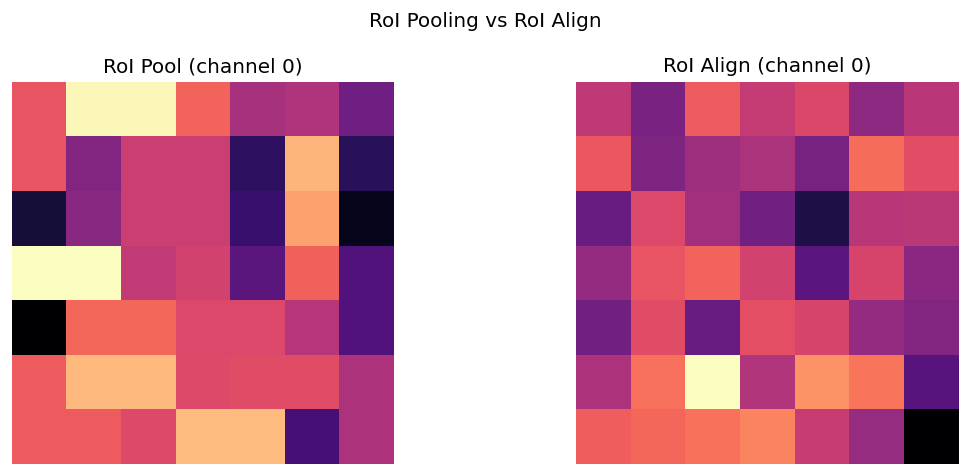

In [ ]:
# === Section 3 — Head + encode/decode + RoI Align ===

def _centers_from_xyxy(boxes: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    w = (x2 - x1).clamp(min=1e-6)
    h = (y2 - y1).clamp(min=1e-6)
    cx = x1 + 0.5 * w
    cy = y1 + 0.5 * h
    return cx, cy, w, h


def encode_boxes(anchors: torch.Tensor, gt_boxes: torch.Tensor) -> torch.Tensor:
    """Encode gt_boxes relative to anchors as (dx, dy, dw, dh)."""
    a_cx, a_cy, a_w, a_h = _centers_from_xyxy(anchors)
    g_cx, g_cy, g_w, g_h = _centers_from_xyxy(gt_boxes)
    dx = (g_cx - a_cx) / a_w
    dy = (g_cy - a_cy) / a_h
    dw = torch.log(g_w / a_w)
    dh = torch.log(g_h / a_h)
    return torch.stack([dx, dy, dw, dh], dim=1)


def decode_boxes(anchors: torch.Tensor, deltas: torch.Tensor) -> torch.Tensor:
    """Decode (dx,dy,dw,dh) back into xyxy boxes."""
    a_cx, a_cy, a_w, a_h = _centers_from_xyxy(anchors)
    dx, dy, dw, dh = deltas[:, 0], deltas[:, 1], deltas[:, 2], deltas[:, 3]
    pred_cx = dx * a_w + a_cx
    pred_cy = dy * a_h + a_cy
    pred_w = torch.exp(dw) * a_w
    pred_h = torch.exp(dh) * a_h
    x1 = pred_cx - 0.5 * pred_w
    y1 = pred_cy - 0.5 * pred_h
    x2 = pred_cx + 0.5 * pred_w
    y2 = pred_cy + 0.5 * pred_h
    return torch.stack([x1, y1, x2, y2], dim=1)


# Quick encode/decode sanity check
anchors_demo = torch.tensor([[10, 10, 50, 50], [40, 20, 90, 70]], dtype=torch.float32)
gt_demo = torch.tensor([[12, 11, 52, 49], [42, 18, 100, 74]], dtype=torch.float32)
deltas = encode_boxes(anchors_demo, gt_demo)
decoded = decode_boxes(anchors_demo, deltas)
print('Decoded close to gt (allclose):', bool(torch.allclose(decoded, gt_demo, atol=1e-4)))

# RoI Pooling vs RoI Align visualization
C, H, W = 32, 20, 20
feat = torch.randn(1, C, H, W, device=device)
# roi tensor for torchvision.ops expects [batch_idx, x1, y1, x2, y2]
roi = torch.tensor([[0, 6.2, 7.3, 15.8, 17.1]], dtype=torch.float32, device=device)
out_size = (7, 7)
pooled = torchvision.ops.roi_pool(feat, roi, output_size=out_size, spatial_scale=1.0)
aligned = torchvision.ops.roi_align(feat, roi, output_size=out_size, spatial_scale=1.0, aligned=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(pooled[0, 0].detach().cpu().numpy(), cmap='magma')
axes[0].set_title('RoI Pool (channel 0)')
axes[0].axis('off')
axes[1].imshow(aligned[0, 0].detach().cpu().numpy(), cmap='magma')
axes[1].set_title('RoI Align (channel 0)')
axes[1].axis('off')
fig.suptitle('RoI Pooling vs RoI Align')
plt.tight_layout()
out_path = fig_dir / 'roi_pool_vs_align.png'
#plt.savefig(out_path)
plt.show()
#print('Saved:', out_path)



# 4 - NMS ( Non Maximum Suppresion )
<a id="sec4"></a>

<p>
In object detection, a model doesn't output a single bounding box per object — it outputs hundreds or thousands of candidate boxes, many of which heavily overlap around the same object. NMS is the post-processing algorithm that keeps only the best box per object and discards the rest.Without NMS, your model would detect the same car 47 times. With NMS, it detects it once.

The Core Idea
Every candidate box comes with two pieces of information:

A bounding box [x1, y1, x2, y2]
A confidence score — how sure the model is that there's an object there

NMS uses the Intersection over Union (IoU) metric to decide which overlapping boxes refer to the same object.

If two boxes have a high IoU (e.g. > 0.5), they're almost certainly detecting the same object, *so only the higher-confidence one survives.*

</p>

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/nms.png">

## 4.1 NMS from scratch (synthetic demo)

NMS kept indices: [0, 2]


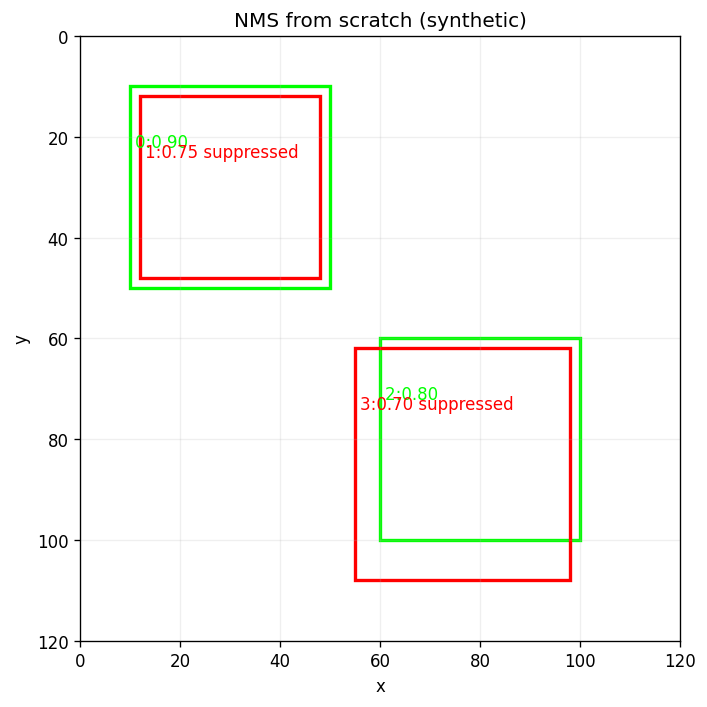

In [12]:
# NMS demo on synthetic boxes
def nms_pytorch(boxes: torch.Tensor, scores: torch.Tensor, iou_threshold: float = 0.5) -> torch.Tensor:
    """Class-agnostic NMS (xyxy)."""
    if boxes.numel() == 0:
        return torch.empty((0,), dtype=torch.int64)

    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    order = scores.argsort(descending=True)
    keep: List[int] = []

    while order.numel() > 0:
        i = int(order[0].item())
        keep.append(i)
        if order.numel() == 1:
            break

        rest = order[1:]
        xx1 = torch.maximum(x1[i], x1[rest])
        yy1 = torch.maximum(y1[i], y1[rest])
        xx2 = torch.minimum(x2[i], x2[rest])
        yy2 = torch.minimum(y2[i], y2[rest])

        inter = (xx2 - xx1).clamp(min=0) * (yy2 - yy1).clamp(min=0)
        iou = inter / (areas[i] + areas[rest] - inter + 1e-7)
        order = rest[iou <= iou_threshold]

    return torch.tensor(keep, dtype=torch.int64)


boxes_demo = torch.tensor([[10, 10, 50, 50], [12, 12, 48, 48], [60, 60, 100, 100], [55, 62, 98, 108]], dtype=torch.float32)
scores_demo = torch.tensor([0.9, 0.75, 0.8, 0.7], dtype=torch.float32)
keep_idx = nms_pytorch(boxes_demo, scores_demo, iou_threshold=0.5)
print('NMS kept indices:', keep_idx.tolist())

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.set_title('NMS from scratch (synthetic)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0, 120)
ax.set_ylim(120, 0)
ax.grid(True, alpha=0.2)

for i, b in enumerate(boxes_demo):
    x1, y1, x2, y2 = b.tolist()
    color = 'lime' if i in keep_idx.tolist() else 'red'
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1 + 1, y1 + 12, f'{i}:{scores_demo[i]:.2f} {"" if i in keep_idx else "suppressed"}', color=color)

out_path2 = fig_dir / 'nms_synthetic_demo.png'
plt.tight_layout()
#plt.savefig(out_path2)
plt.show()
#print('Saved:', out_path2)

<a id="sec-metrics"></a>

---

# 5. Evaluation metrics in computer vision

Once a model is trained, **loss** tells you how optimisation is going — but **metrics** tell you whether predictions are *useful* on held-out data. The right metric depends on the **task** (classification vs detection) and on **what errors you care about** (missed objects, wrong labels, sloppy boxes, etc.).

Below are four of the most cited numbers in papers and leaderboards, with a consistent detection-friendly story that connects back to **IoU** from earlier sections.

---

## 5.1 Accuracy

**What it measures (classification).**  
For *single-label* image classification, **accuracy** is the fraction of images whose **predicted class** equals the **ground-truth class**:

$$\text{Accuracy} = \frac{\mathrm{ correct predictions}}{\mathrm{ samples}}$$

- **Strength:** easy to communicate (“the model got 92% of images right”).
- **Limits:** with **imbalanced** classes, accuracy can look high while the model ignores rare classes. In that setting people also report **per-class accuracy**, **balanced accuracy**, or **macro-F1**.

> **Detection caveat:** Raw “classification accuracy” alone does not summarise object detection, because each image can have **many** objects and each prediction is a **(class, box)** pair. Detection benchmarks instead centre on **precision–recall curves** and **mAP** (below).

---

## 5.2 Recall

**What it measures.**  
Recall answers: *of all the ground-truth positives, how many did we find?*

$$\text{Recall} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}$$

- **TP (true positives):** predictions matched to a ground-truth object according to the task rules (for detection: usually **IoU** above a threshold **and** correct class).
- **FN (false negatives):** ground-truth objects with **no** acceptable matching prediction — the model **missed** them.

High recall means fewer **missed objects** — critical in applications like **autonomous driving** or **medical imaging**, where overlooking an instance can be catastrophic.

> **Pairing with precision.** In detection, **precision** = $\mathrm{TP} / (\mathrm{TP} + \mathrm{FP})$ asks how many predicted boxes are “real” vs spurious. Papers often report **precision–recall curves**; mAP summarises that curve in a single number.

---
## 5.3 Precision 

**Precision** is a metric used to evaluate the quality of a classification model, especially in tasks like binary classification, object detection, and information retrieval.

> **Precision measures how many of the predicted positive instances are actually correct.**

$$\text{Precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}$$


Where:

* **TP (True Positives):** Correctly predicted positive cases
* **FP (False Positives):** Incorrectly predicted positive cases

Precision answers the question:

> *"When the model predicts positive, how often is it right?"*

A **high precision** means:

* Few false positives
* The model is **conservative** when predicting positives

### 📊 Example

Suppose a model predicts whether an email is spam:

|                     | Predicted Spam | Predicted Not Spam |
| ------------------- | -------------- | ------------------ |
| **Actual Spam**     | 40 (TP)        | 10 (FN)            |
| **Actual Not Spam** | 5 (FP)         | 45 (TN)            |

`P = ( 40/40+5 ) = 0.89`

👉 This means **89% of emails predicted as spam are actually spam**.

---

## 5.3 mAP@50 (AP at IoU = 0.50)

**Context: object detection.**  
A predicted box is typically counted as a **true positive** for a ground-truth box if:

1. the **class label** matches, and  
2. $\mathrm{IoU}(\text{pred}, \text{gt}) \geq \tau$ for a fixed threshold $\tau$.

**mAP@50** uses **$\tau = 0.5$** — a relatively **lenient** localisation bar.

**How AP is built (high level).**  
For each class, sort predictions by **confidence**, match them greedily to ground truths (each GT used once), and sweep a threshold on confidence. Plot **precision vs recall**; **Average Precision (AP)** is essentially the **area under that PR curve** .

**mAP** averages AP over **classes** (and sometimes over **images** in the dataset, depending on the benchmark protocol).

| Aspect | mAP@50 |
|--------|--------|
| **Localisation strictness** | Moderate — box must overlap GT with **IoU ≥ 0.5** |
| **Typical use** | Quick sense of “does the detector find objects in roughly the right place?” |

---

## 5.4 mAP@[50:95] — “mAP50-95” or COCO-style mAP

**Stricter localisation.**  
Instead of a **single** IoU threshold, COCO-style **mAP** averages AP over **multiple** thresholds:

$$\tau \in \{0.50,\, 0.55,\, 0.60,\, \ldots,\, 0.95\}$$

(step **0.05**), then averages those APs. Informally:

$$\text{mAP} \approx \frac{1}{10}\sum_{k=0}^{9} \text{AP @ IoU} = (0.50 + 0.05k)$$

So **mAP50-95** rewards detectors that stay accurate when IoU must be **0.75**, **0.9**, etc. — not only at **0.5**. Two models can have **similar mAP@50** but very **different mAP50-95** if one produces **sloppier** boxes.

| Metric | What tightens / relaxes |
|--------|-------------------------|
| **mAP@50** | Easier localisation |
| --- | --- |
| **mAP@50–95** | Harder — must work across **many** IoU cut-offs |

---

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/metrics.png">

## One-page mental map

| Metric | Task focus | One-line intuition |
|--------|------------|--------------------|
| **Accuracy** | Classification | “Did we pick the **right label** for this image?” |
| **Recall** | Any task with positives | “Did we **find** most of the true objects (or positives)?” |
| **mAP@50** | Detection | “How good are we at **class + box** when IoU ≥ **0.5**?” |
| **mAP@50–95** | Detection | “How good are we when boxes must be **tighter**, averaged over many IoU levels?” |

---

### Takeaway

- Use **accuracy** for **global class correctness** in classification; complement it when data are **imbalanced**.  
- Use **recall** when **missing instances** is costly.  
- Use **mAP@50** and **mAP@50–95** to report **object detection** quality with a clear, benchmark-aligned localisation story tied to **IoU**.

# Section 5 — Loss Functions (Multi-task Learning)
<a id="sec5"></a>
---


## 5.1 Classification Loss Functions

### 5.1.1 Cross-Entropy
---

Cross-entropy measures **how well a predicted probability distribution matches the true distribution**. It's the most common loss function for classification tasks.

### Intuition :

Imagine you're a forecaster. If you say "90% chance of rain" and it rains, great — low penalty. If you say "10% chance of rain" and it rains, you're punished heavily. Cross-entropy formalizes this: **confident wrong predictions are penalized much more than uncertain ones**.


### Formula :

For a single sample with true label $y$ and predicted probability $\hat{y}$:

**Binary classification:**
$$\mathcal{L} = -\left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$

**Multi-class classification** (C classes):
$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

Since $y_c$ is one-hot (only one class is 1), this simplifies to just:
$$\mathcal{L} = -\log(\hat{y}_{\text{true class}})$$


### Why the `-log`?

The key is the shape of $-\log(p)$:

| Predicted prob for true class | Loss |
|---|---|
| 0.99 | ≈ 0.01 (almost no penalty) |
| 0.50 | ≈ 0.69 |
| 0.10 | ≈ 2.30 |
| 0.01 | ≈ 4.60 (heavy penalty) |

It's **asymmetric and nonlinear** — being confidently wrong is catastrophic.

### 5.1.2 Focal Loss — Fighting class imbalance
---

### The problem it solves

<p>
In a single-stage detector (like RetinaNet or YOLO), the model evaluates ~100,000 candidate locations per image. 

The overwhelming majority are easy negatives — patches of sky, road, background. Only a handful contain actual objects.

Standard Cross-Entropy gives all examples equal weight. The result: the model drowns in easy background examples. The gradient signal from the few hard, interesting examples gets buried.

</p>

### The Mechanism of Focusing

<p>
The core innovation of Focal Loss lies in its ability to dynamically scale the penalty assigned to each sample based on the model's confidence. In a typical supervised learning scenario, a detector might evaluate thousands of candidate locations in an image. Since most of these locations contain no objects, a standard loss function accumulates many small error signals from these easy negatives, which can drown out the valuable signal from the few positive instances.

Focal Loss introduces a modulating factor that decays the loss contribution as the confidence in the correct class increases. This means that if a model is already 99% sure that a background patch is indeed background, the loss for that patch is reduced to near zero. Consequently, the model weights are updated primarily based on misclassified samples or those where the model is uncertain. This targeted approach is essential for training high-performance one-stage object detectors like YOLO26, allowing them to achieve high accuracy without requiring complex sampling stages.
</p>
<p>

```text
FL(p_t) = -α_t · (1 - p_t)^γ · log(p_t)
           ───┬───   ───┬────
              │         └── focusing term: suppresses easy examples
              └── class balancing weight (α ≈ 0.25 for foreground)
```

The ```(1 - p_t)^γ``` term is the key insight. When the model is confident *(p_t → 1)*, this *factor → 0*, effectively muting the loss contribution from easy examples. Hard examples (where p_t is low) retain nearly their full loss signal.
</p>



### Focal Loss vs. Cross-Entropy Loss

<p>
Cross-Entropy is the foundational metric for classification that penalizes predictions based on logarithmic error. 

Focal Loss is strictly an extension of Cross-Entropy; if the focusing parameter is set to zero, it mathematically reverts to standard Cross-Entropy. 

The key distinction is Focal Loss's ability to automatically down-weight easy negatives, making it superior for imbalanced datasets like COCO.
</p>



## 5.2 Loss Functions for Bounding Box Detection
---

A detector predicts 4 numbers per box. The loss function measures how wrong those 4 numbers are — and its shape determines what the model actually learns to optimize. The field has evolved through several generations, each fixing a blind spot in the previous one.


### What is the model actually predicting?

Most detectors predict **offsets** relative to an anchor box, which are then decoded into absolute coordinates:

```text
Predicted:   (tx, ty, tw, th)   ← raw network outputs
Decoded:     (cx, cy, w, h)     ← actual box coordinates
             or (x1, y1, x2, y2)
```

The regression loss operates on these 4 values against the ground truth box.

---

### 5.2.1 L2 Loss (MSE)

The naive starting point: minimize the sum of squared coordinate errors.

```text
L_L2 = (x1_pred − x1_gt)² + (y1_pred − y1_gt)²
      + (x2_pred − x2_gt)² + (y2_pred − y2_gt)²
```

It works, but has two fatal problems:

- A single outlier box with a large error generates a **massive gradient** (`error²` blows up), destabilizing training.
- It treats all 4 coordinates as independent — there's **no notion of geometric overlap**. A box 10px off in `x` gets the same penalty whether that shifts it completely off the object or barely changes the overlap.

---

### 5.2.2 Smooth L1 (Huber Loss)

Introduced in Faster R-CNN (2015). Fixes the outlier explosion by stitching L2 near zero with L1 for large errors:

```text
           ⎧  0.5 · x²               if |x| < δ    ← smooth, stable gradient
SL1(x) =  ⎨
           ⎩  δ · (|x| − 0.5·δ)     if |x| ≥ δ    ← linear, bounded gradient
```

Applied per-coordinate, summed:

```text
L_SL1 = SL1(Δx) + SL1(Δy) + SL1(Δw) + SL1(Δh)
```

The key property: the gradient is capped at `±δ` for large errors. A wildly wrong box prediction can't explode the gradient and corrupt the batch.

However, it still treats the 4 coordinates as **independent scalars**. The true quality of a detection is its overlap with ground truth — Smooth L1 doesn't optimize that directly.

---

### 5.2.3 IoU Loss

The natural idea: just minimize `1 − IoU` directly.

```text
L_IoU = 1 − IoU(B_pred, B_gt)

         area(B_pred ∩ B_gt)
IoU =  ─────────────────────────
         area(B_pred ∪ B_gt)
```

This is **scale-invariant** — a small box 5px off is penalized similarly to a large box 50px off, which is exactly right. And it directly optimizes the metric you actually care about (IoU at test time).

The critical failure: **when boxes don't overlap, IoU = 0, gradient = 0.** The loss is flat everywhere outside the ground truth box. The model gets no signal about which direction to move a non-overlapping prediction.

```text
Box A = [0,0,10,10]    Box B = [20,0,30,10]  →  IoU = 0,  Loss = 1
Box A = [0,0,10,10]    Box B = [200,0,210,10] → IoU = 0,  Loss = 1  ← identical!
```

Two completely different situations, same loss, same gradient (zero). Training stalls whenever boxes don't overlap at initialization.
<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/iou.webp">

### 5.2.4 GIoU Loss
---

*Generalized IoU* (Rezatofighi et al., CVPR 2019). Adds a penalty based on the **smallest enclosing box** `C` that contains both boxes:

```text
              |C| − |B_pred ∪ B_gt|
GIoU = IoU − ─────────────────────
                      |C|

L_GIoU = 1 − GIoU    ∈ [0, 2]
```

The penalty term `(|C| − |A ∪ B|) / |C|` is the fraction of the enclosing box that's empty — not covered by either prediction or target. When boxes are far apart, this term grows large, giving a meaningful gradient even with zero overlap.

| Situation | IoU | GIoU | Gradient? |
|-----------|-----|------|-----------|
| Perfect overlap | 1 | 1 | zero loss |
| Partial overlap | 0.4 | 0.3 | yes — from both terms |
| No overlap, nearby | 0 | −0.1 | yes — from enclosing box |
| No overlap, far | 0 | −0.8 | yes — stronger signal |

GIoU ∈ `[−1, 1]` always. The model always knows which way to move.

**Remaining weakness**: when one box is fully inside the other (nested boxes), GIoU collapses to plain IoU — the enclosing box penalty vanishes and the gradient becomes weak.

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/giou.webp">


### 5.2.5 DIoU Loss
---

*Distance IoU* (Zheng et al., AAAI 2020). Adds a penalty for the **distance between box centers**:
<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/diou.webp">
```text
                    ρ²(b_pred, b_gt)
DIoU = IoU −  ─────────────────────────
                       c²

where  ρ = Euclidean distance between centers
       c = diagonal of enclosing box C

L_DIoU = 1 − DIoU
```

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/diou2.webp">

The center-distance term pushes the predicted box's center toward the target's center, even when one box is nested inside the other. Convergence is faster than GIoU because the gradient signal is more direct.

---

### 5.2.6 CIoU Loss

*Complete IoU* (same paper). Adds a third term: **aspect ratio consistency**.

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/ciou.webp" width=400 heigth=400>

CIoU simultaneously penalizes three geometric discrepancies:

```text
Overlap area  +  Center distance  +  Aspect ratio
   (IoU)           (ρ²/c²)              (α·v)
```

This is the loss used in YOLOv5, YOLOv8, and most modern single-stage detectors.

### Full comparison at a glance
---

| Loss | Scale-invariant | No-overlap gradient | Center-aware | Aspect-ratio aware | Used in |
|------|:-:|:-:|:-:|:-:|---------|
| L2 (MSE) | no | yes | no | no | early detectors |
| Smooth L1 | no | yes | no | no | Faster R-CNN, older YOLO |
| IoU | yes | no | no | no | baseline |
| GIoU | yes | yes | no | no | DETR |
| DIoU | yes | yes | yes | no | YOLOv4 |
| CIoU | yes | yes | yes | yes | YOLOv5, v8, DINO |

### What "scale-invariant" means in practice

Smooth L1 operates on raw pixel differences. A box predicted 10px off on a 20px object is catastrophically wrong. The same 10px error on a 500px object is trivial. Smooth L1 penalizes both equally.

IoU-family losses don't have this problem — they measure geometric overlap ratios, which are naturally normalized. A 50% overlap is 50% regardless of the object's absolute size.

<img src="https://raw.githubusercontent.com/EzequielMatiasArevalo/tuia-computer-vision/refs/heads/main/content/loss_histogram.webp" width=400 heigh=400>



---

### How they combine in a real detector

Modern detectors use a weighted combination — classification and box regression have separate loss branches:

```text
Total Loss = λ₁ · L_cls  +  λ₂ · L_box  +  λ₃ · L_obj

where:
  L_cls  = Focal Loss (for class probability — handles imbalance)
  L_box  = CIoU Loss (for box coordinates — geometry-aware)
  L_obj  = BCE (for objectness score — is there an object at all?)

  λ₁=1.0, λ₂=5.0, λ₃=1.0  ← YOLOv5 defaults
```

Box regression is weighted higher (`λ₂=5.0`) because precise localization is harder to learn than rough object presence.

---

### The intuition in one sentence per loss

- **Smooth L1** — *"be roughly right on all 4 coordinates, don't let outliers blow up training"*
- **IoU Loss** — *"optimize the overlap directly, but you're stuck if boxes don't touch"*
- **GIoU Loss** — *"always move toward the target, even from across the image"*
- **DIoU Loss** — *"get your center right first, then worry about size"*
- **CIoU Loss** — *"match center, shape, AND aspect ratio — be completely right"*

In [13]:
import torch
from torchvision.ops import generalized_box_iou, distance_box_iou, complete_box_iou
import torch.nn.functional as F

pred_boxes = torch.tensor([[50., 60., 180., 190.]])   # (x1,y1,x2,y2)
gt_boxes   = torch.tensor([[80., 90., 220., 200.]])

# ── Smooth L1 (on offset space, before decoding) ──────────────────────────────
pred_offsets = torch.tensor([[0.1, -0.2, 0.05, 0.3]])
gt_offsets   = torch.tensor([[0.0,  0.0, 0.0,  0.0]])
smooth_l1 = F.smooth_l1_loss(pred_offsets, gt_offsets, beta=1.0)

# ── IoU family (on decoded box coordinates) ───────────────────────────────────
iou_val  = generalized_box_iou(pred_boxes, gt_boxes).diag()
giou_loss = (1 - iou_val).mean()

diou_val  = distance_box_iou(pred_boxes, gt_boxes).diag()
diou_loss = (1 - diou_val).mean()

ciou_val  = complete_box_iou(pred_boxes, gt_boxes).diag()
ciou_loss = (1 - ciou_val).mean()

print(f"Smooth L1 : {smooth_l1:.4f}")
print(f"GIoU Loss : {giou_loss:.4f}")
print(f"DIoU Loss : {diou_loss:.4f}")
print(f"CIoU Loss : {ciou_loss:.4f}")

Smooth L1 : 0.0178
GIoU Loss : 0.6146
DIoU Loss : 0.5851
CIoU Loss : 0.5851


# References
---

- Tsung-Yi Lin 2018 | [Focal Loss for Dense Object Detection](https://arxiv.org/pdf/1708.02002)
- Zhaohui Zheng 2019 | [Distance-IoU Loss: Faster and Better Learning for Bounding Box Regression](https://arxiv.org/pdf/1911.08287)
- Hamid Rezatofighi 2019 | [Generalized Intersection over Union: A Metric and A Loss for Bounding Box](https://arxiv.org/pdf/1902.09630)